# Contexte
Une entreprise souhaite développer un système d’intelligence artificielle capable de reconnaître
automatiquement le type de déchet présent sur une photographie afin d'améliorer le tri des
déchets.
Le modèle devra classer chaque image dans l'une des catégories suivantes :

cardboard : cartons ondulés, cartons plats, …

plastic : bouteilles, emballages plastiques...

paper : feuilles, journaux...

glass : bouteilles et objets en verre...

metal : canettes, boîtes métalliques...

trash : emballages bonbons, tasses jetables, ...

Le problème est que les images collectées proviennent de plusieurs sources. Elles ne sont donc pas
homogènes : dimensions différentes ; formats différents ; images RGB et grayscale ; certaines images
sont trop petites ; certaines images sont corrompues ; quelques images sont vides ; images
dupliquées ; quelques images placées dans le mauvais dossier ; classes déséquilibrées.

L'objectif de l'atelier est donc de construire un jeu de données images propre et homogène, prêt à
être utilisé pour entraîner un modèle de Machine Learning ou de Deep Learning.

In [35]:
# Importation des bibliotheque
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from tqdm.auto import tqdm
from PIL import Image
from pathlib import Path


# Partie 1 – Exploration du dataset
Développer un programme Python capable de récupérer, pour chaque image, son nom, sa classe,
son format, son mode, sa largeur, sa hauteur, l’écart-type de ses pixels, son nombre de canaux et sa
taille.
NB : prendre en charge aussi les fichiers corrompus

In [36]:
# Liste de tous les chemain de fichiers
RAW_DIR = Path("../data/raw")

fichiers = []
for dossier_classe in sorted(RAW_DIR.iterdir()):
    if dossier_classe.is_dir():
        for fichier in sorted(dossier_classe.iterdir()):
            if fichier.is_file():
                fichiers.append(fichier)

print(len(fichiers), "fichiers trouvés")
print(fichiers[0:2])


1032 fichiers trouvés
[PosixPath('../data/raw/cardboard/cardboard1.jpg'), PosixPath('../data/raw/cardboard/cardboard10.jpg')]


In [37]:
# fonction inspection de l'image
def inspect_image(chemin):
    # 1) La fiche : les infos qu'on peut toujours obtenir, le reste à None
    fiche = {
        "name": chemin.name,
        "class": chemin.parent.name,
        "format": None,
        "mode": None,
        "width": None,
        "height": None,
        "channels": None,
        "pixel_std": None,
        "file_size_kb": round(chemin.stat().st_size / 1024, 2),
        "corrupted": False,
    }

    # 2) On essaie de lire l'image
    try:
        with Image.open(chemin) as img:
            img.load()                                   # lit tous les pixels
            fiche["format"] = img.format
            fiche["mode"] = img.mode
            fiche["width"] = img.width
            fiche["height"] = img.height
            fiche["channels"] = len(img.getbands())
            gris = np.asarray(img.convert("L"))
            fiche["pixel_std"] = float(gris.std())

    # 3) Si une erreur se produit, l'image est corrompue
    except Exception as e:
        fiche["corrupted"] = True

    return fiche

In [38]:
toutes_les_fiches = []

for f in tqdm (fichiers):
    fiche = inspect_image(f)
    toutes_les_fiches.append(fiche)

print(len(toutes_les_fiches), "fiches creees")

  0%|          | 0/1032 [00:00<?, ?it/s]

1032 fiches creees


In [39]:
df = pd.DataFrame(toutes_les_fiches)
for colonne in ["width", "height","channels"]:
    df[colonne] = df[colonne].astype("Int64")
df.head(636)

,name,class,format,mode,width,height,channels,pixel_std,file_size_kb,corrupted
0,cardboard1.jpg,cardboard,JPEG,RGB,512,384,3,31.875892,16.93,False
1,cardboard10.jpg,cardboard,JPEG,RGB,512,384,3,38.799907,21.17,False
2,cardboard100.jpg,cardboard,JPEG,RGB,512,384,3,44.498372,14.54,False
3,cardboard101.jpg,cardboard,JPEG,RGB,512,384,3,68.561937,13.95,False
4,cardboard102.jpg,cardboard,JPEG,RGB,512,384,3,45.320633,17.59,False
...,...,...,...,...,...,...,...,...,...,...
631,paper211.jpg,paper,JPEG,RGB,512,384,3,29.630460,16.90,False
632,paper212.jpg,paper,JPEG,RGB,512,384,3,28.926619,11.68,False
633,paper213.jpg,paper,NaN,NaN,<NA>,<NA>,<NA>,NaN,7.12,True
634,paper214.jpg,paper,JPEG,RGB,512,384,3,63.676604,47.69,False


# Partie 2 – Détecter les images corrompues
Écrire et se servir d’une fonction qui détecte une image corrompue.

In [40]:
def is_corrupted_image(chemin):
    try:
        # le fichier est-il vide ? 
        if chemin.stat().st_size == 0:
            return True, "fichier vide (0 octet)"
        
        # la structure du fichier est-elle coherente?
        with Image.open(chemin) as img: 
            img.verify()
        # Peut-on lire tous les pixels?
        with Image.open(chemin) as img:
            img.load()

        return False, ""  # L'image est valide
    
    except Exception as e:
        print(f"Erreur lors de l'ouverture de l'image {chemin} : {e}")
        return True, str(e)[:100]


In [41]:
resultats = [is_corrupted_image(f) for f in tqdm(fichiers)]

df["is_corrupted_image"] = [r[0] for r in resultats]    # les True / False
df["motif"] = [r[1] for r in resultats]           # les messages d'erreur

  0%|          | 0/1032 [00:00<?, ?it/s]

Erreur lors de l'ouverture de l'image ../data/raw/cardboard/cardboard83.jpg : cannot identify image file '../data/raw/cardboard/cardboard83.jpg'
Erreur lors de l'ouverture de l'image ../data/raw/glass/glass74.jpg : Truncated File Read
Erreur lors de l'ouverture de l'image ../data/raw/metal/metal48.jpg : cannot identify image file '../data/raw/metal/metal48.jpg'
Erreur lors de l'ouverture de l'image ../data/raw/paper/paper213.jpg : cannot identify image file '../data/raw/paper/paper213.jpg'
Erreur lors de l'ouverture de l'image ../data/raw/plastic/plastic13.jpg : cannot identify image file '../data/raw/plastic/plastic13.jpg'
Erreur lors de l'ouverture de l'image ../data/raw/trash/trash3.jpg : cannot identify image file '../data/raw/trash/trash3.jpg'


In [42]:
n = df["is_corrupted_image"].sum()
print(f"Images corrompues : {n} / {len(df)} ({100 * n / len(df):.2f} %)")

# Le détail des fichiers corrompus
df[df["is_corrupted_image"]][["name", "class", "file_size_kb", "motif"]]

Images corrompues : 6 / 1032 (0.58 %)


,name,class,file_size_kb,motif
147,cardboard83.jpg,cardboard,20.40,cannot identify image file '../data/raw/cardbo...
326,glass74.jpg,glass,7.02,Truncated File Read
446,metal48.jpg,metal,7.09,cannot identify image file '../data/raw/metal/...
633,paper213.jpg,paper,7.12,cannot identify image file '../data/raw/paper/...
791,plastic13.jpg,plastic,5.13,cannot identify image file '../data/raw/plasti...
1004,trash3.jpg,trash,8.98,cannot identify image file '../data/raw/trash/...


# Partie 3 – Détecter les images vides
Écrire et se servir d’une fonction qui détecte les images vides : image entièrement noire, image
entièrement blanche ou image dont les pixels présentent très peu de variation.

On fixe un seuil : en dessous de 5 (sur une échelle de 0 à 255), l'image est considérée comme vide. Pour savoir de quel type de vide il s'agit, on regarde la moyenne des pixels :


| Écart-type | Moyenne | Diagnostic |
| :--- | :--- | :--- |
| ≥ 5 | (peu importe) | Image normale |
| < 5 | ≤ 10 (proche de 0) | Image noire |
| < 5 | ≥ 245 (proche de 255) | Image blanche |
| < 5 | Entre les deux | Faible variation (gris ou couleur unie) |


In [44]:
SEUIL_STD = 5      # en dessous, l'image est considérée comme vide

def is_empty_image(chemin, seuil=SEUIL_STD):
    """Retourne (vide, type, écart-type). Type : 'noire', 'blanche', 'faible_variation' ou ''."""
    with Image.open(chemin) as img:
        gris = np.asarray(img.convert("L"), dtype=np.float32)   # tableau de pixels en gris

    ecart_type = float(gris.std())
    moyenne = float(gris.mean())

    if ecart_type >= seuil:
        return False, "", ecart_type          # image normale
    if moyenne <= 10:
        return True, "noire", ecart_type
    if moyenne >= 245:
        return True, "blanche", ecart_type
    return True, "faible_variation", ecart_type

In [46]:
df["is_empty"] = False
df["empty_type"] = ""

for i in tqdm(df.index):
    if df.at[i, "is_corrupted_image"]:          # image illisible : on passe
        continue
    vide, type_vide, _ = is_empty_image(fichiers[i])
    df.at[i, "is_empty"] = vide
    df.at[i, "empty_type"] = type_vide

  0%|          | 0/1032 [00:00<?, ?it/s]

In [47]:
print("Images quasi vides :", df["is_empty"].sum())
print(df[df["is_empty"]]["empty_type"].value_counts())
df[df["is_empty"]][["name", "class", "empty_type", "pixel_std"]]

Images quasi vides : 4
empty_type
blanche    2
noire      2
Name: count, dtype: int64


,name,class,empty_type,pixel_std
167,image-blanche-512x384.jpg,cardboard,blanche,1.132032
355,image-noire-512x384.png,glass,noire,0.000000
357,image-blanche-512x384.jpg,metal,blanche,1.132032
358,image-noire-512x384.png,metal,noire,0.000000


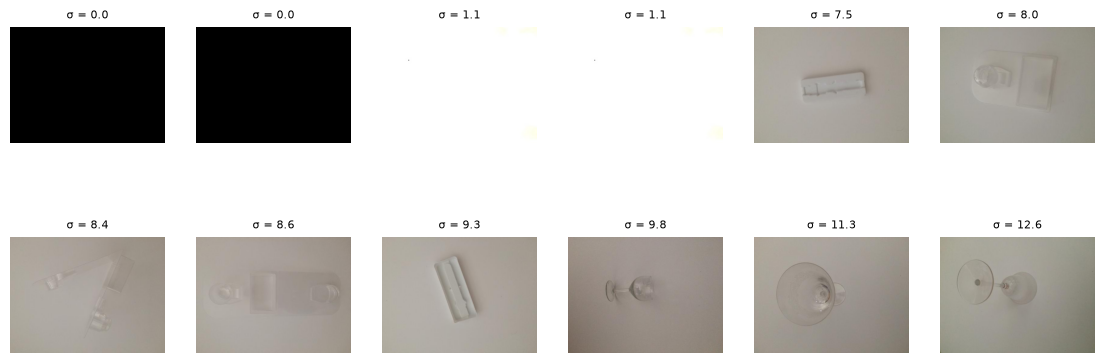

In [ ]:
#verification

valides = df[~df["is_corrupted_image"]]

plus_bas = valides.nsmallest(12, "pixel_std")       # les 12 plus petits écarts-types

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, (i, ligne) in zip(axes.ravel(), plus_bas.iterrows()):
    ax.imshow(Image.open(fichiers[i]).convert("RGB"))
    ax.set_title(f"σ = {ligne['pixel_std']:.1f}", fontsize=8)
    ax.axis("off")
plt.show()